# 01. EDA
Подробный EDA для X5 RetailHero с акцентом на treatment/control, пропуски, смещение и графики.

In [2]:

import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(".."))
from src.utils import load_config, ensure_dir
from src.eda import basic_overview, missing_report, conversion_by_group, observed_uplift, smd_report

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

config = load_config("../configs/config.yaml")
raw_dir = Path("..") / config["paths"]["raw_dir"]
fig_dir = ensure_dir(Path("..") / config["paths"]["figures_dir"])
tbl_dir = ensure_dir(Path("..") / config["paths"]["tables_dir"])
cols = config["columns"]


In [3]:

clients = pd.read_csv(raw_dir / config["files"]["clients"], parse_dates=[cols["first_issue_date"], cols["first_redeem_date"]], low_memory=False)
products = pd.read_csv(raw_dir / config["files"]["products"], low_memory=False)
train = pd.read_csv(raw_dir / config["files"]["uplift_train"], low_memory=False)
test = pd.read_csv(raw_dir / config["files"]["uplift_test"], low_memory=False)

overview = pd.concat([
    basic_overview(clients, "clients"),
    basic_overview(products, "products"),
    basic_overview(train, "uplift_train"),
    basic_overview(test, "uplift_test")
], ignore_index=True)
display(overview)
overview.to_csv(tbl_dir / "table_overview.csv", index=False)


,table,rows,cols,duplicates,missing_total
0,clients,400162,5,0,35469
1,products,43038,11,0,6821
2,uplift_train,200039,3,0,0
3,uplift_test,200123,1,0,0


In [4]:

clients_missing = missing_report(clients)
products_missing = missing_report(products)
train_missing = missing_report(train)

display(clients_missing.head(10))
display(products_missing.head(10))
display(train_missing.head(10))

clients_missing.to_csv(tbl_dir / "clients_missing_report.csv", index=False)
products_missing.to_csv(tbl_dir / "products_missing_report.csv", index=False)
train_missing.to_csv(tbl_dir / "train_missing_report.csv", index=False)


,feature,missing_ratio,missing_pct
0,first_redeem_date,0.088637,8.86
1,client_id,0.000000,0.00
2,first_issue_date,0.000000,0.00
3,age,0.000000,0.00
4,gender,0.000000,0.00


,feature,missing_ratio,missing_pct
0,brand_id,0.120823,12.08
1,segment_id,0.036526,3.65
2,vendor_id,0.000790,0.08
3,level_1,0.000070,0.01
4,level_2,0.000070,0.01
5,level_3,0.000070,0.01
6,level_4,0.000070,0.01
7,netto,0.000070,0.01
8,product_id,0.000000,0.00
9,is_own_trademark,0.000000,0.00


,feature,missing_ratio,missing_pct
0,client_id,0.0,0.0
1,treatment_flg,0.0,0.0
2,target,0.0,0.0


In [5]:

eda_df = train.merge(clients, on=cols["client_id"], how="left")
eda_df.head()


,client_id,treatment_flg,target,first_issue_date,first_redeem_date,age,gender
0,000012768d,0,1,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U
1,000036f903,1,1,2017-04-10 13:54:23,2017-04-23 12:37:56,72,F
2,00010925a5,1,1,2018-07-24 16:21:29,2018-09-14 16:12:49,83,U
3,0001f552b0,1,1,2017-06-30 19:20:38,2018-08-28 12:59:45,33,F
4,00020e7b18,1,1,2017-11-27 11:41:45,2018-01-10 17:50:05,73,U


In [6]:

treatment_dist = eda_df[cols["treatment"]].value_counts(dropna=False).rename_axis("treatment").reset_index(name="count")
treatment_dist["share"] = treatment_dist["count"] / len(eda_df)
display(treatment_dist)
treatment_dist.to_csv(tbl_dir / "treatment_distribution.csv", index=False)


,treatment,count,share
0,0,100058,0.500192
1,1,99981,0.499808


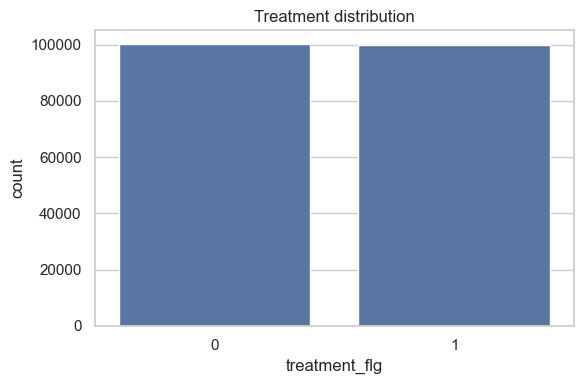

In [7]:

plt.figure(figsize=(6, 4))
sns.countplot(data=eda_df, x=cols["treatment"])
plt.title("Treatment distribution")
plt.tight_layout()
plt.savefig(fig_dir / "eda_treatment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:

conv = conversion_by_group(eda_df, cols["treatment"], cols["target"])
display(conv)
conv.to_csv(tbl_dir / "conversion_by_group.csv", index=False)

uplift_avg = observed_uplift(eda_df, cols["treatment"], cols["target"])
print("Observed average uplift:", round(uplift_avg, 6))


,treatment_flg,conversion_rate,count,positives
0,0,0.603280,100058,60363
1,1,0.636511,99981,63639


Observed average uplift: 0.033231


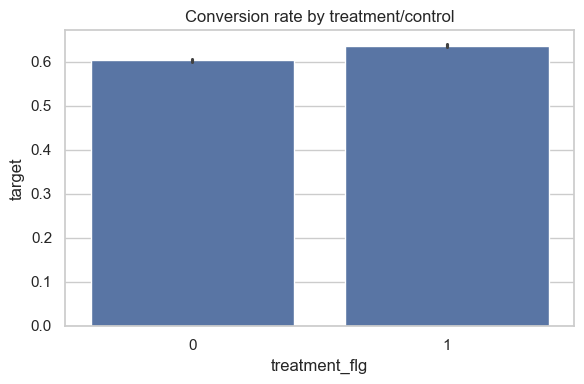

In [9]:

plt.figure(figsize=(6, 4))
sns.barplot(data=eda_df, x=cols["treatment"], y=cols["target"], estimator=np.mean)
plt.title("Conversion rate by treatment/control")
plt.tight_layout()
plt.savefig(fig_dir / "eda_conversion_by_treatment.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:

eda_df["first_issue_date"] = pd.to_datetime(eda_df[cols["first_issue_date"]], errors="coerce")
eda_df["first_redeem_date"] = pd.to_datetime(eda_df[cols["first_redeem_date"]], errors="coerce")
campaign_date = eda_df["first_issue_date"].max().normalize() + pd.Timedelta(days=1)

eda_df["days_since_first_issue"] = (campaign_date - eda_df["first_issue_date"]).dt.days
eda_df["days_since_first_redeem"] = (campaign_date - eda_df["first_redeem_date"]).dt.days
eda_df["has_redeem_history"] = eda_df["first_redeem_date"].notna().astype(int)

numeric_features = [c for c in [cols["age"], "days_since_first_issue", "days_since_first_redeem", "has_redeem_history"] if c in eda_df.columns]
numeric_features


['age',
 'days_since_first_issue',
 'days_since_first_redeem',
 'has_redeem_history']

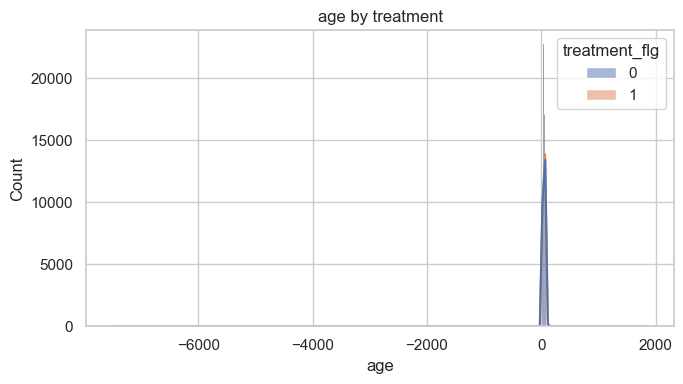

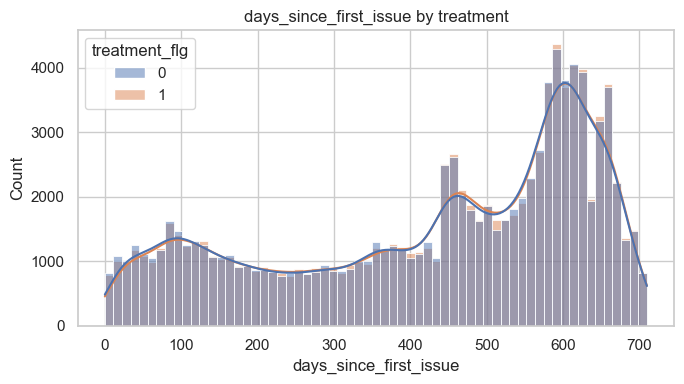

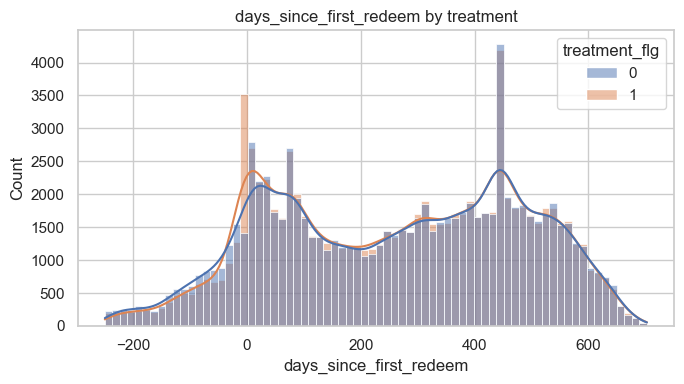

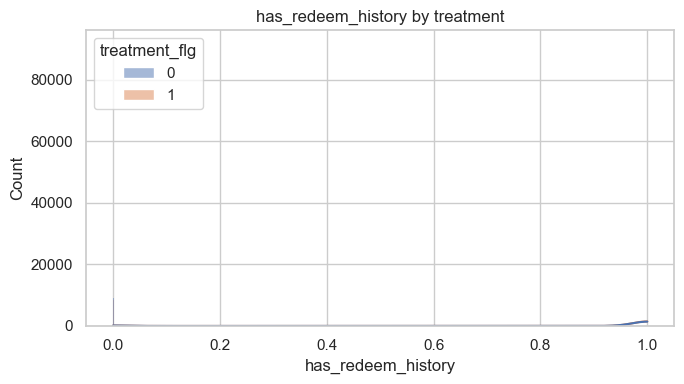

In [11]:

for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=eda_df, x=col, hue=cols["treatment"], kde=True, common_norm=False)
    plt.title(f"{col} by treatment")
    plt.tight_layout()
    plt.savefig(fig_dir / f"eda_hist_{col}.png", dpi=150, bbox_inches="tight")
    plt.show()


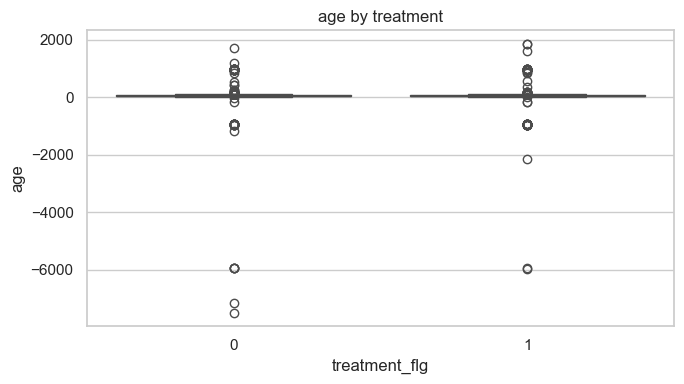

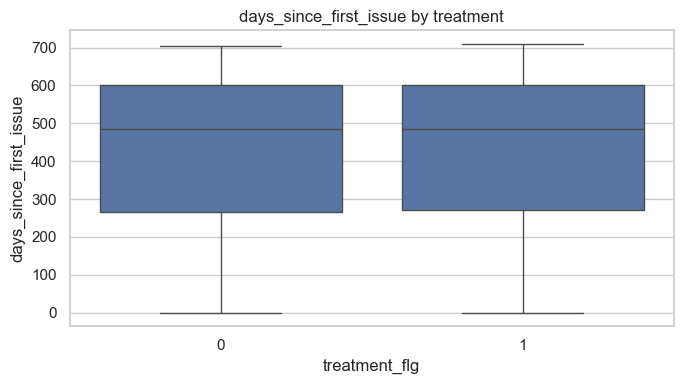

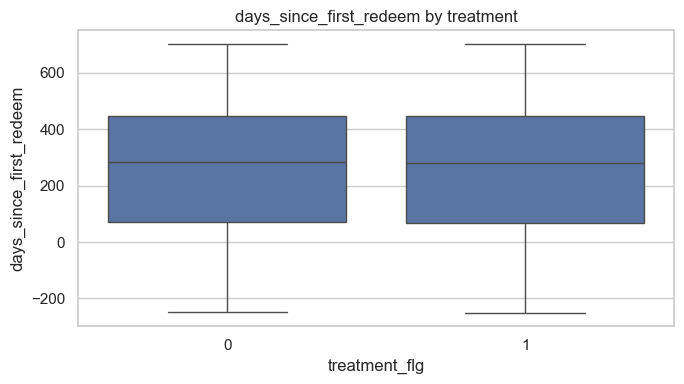

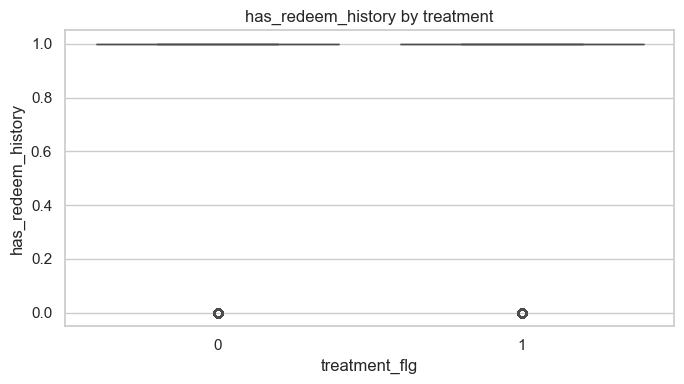

In [12]:

for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=eda_df, x=cols["treatment"], y=col)
    plt.title(f"{col} by treatment")
    plt.tight_layout()
    plt.savefig(fig_dir / f"eda_boxplot_{col}.png", dpi=150, bbox_inches="tight")
    plt.show()


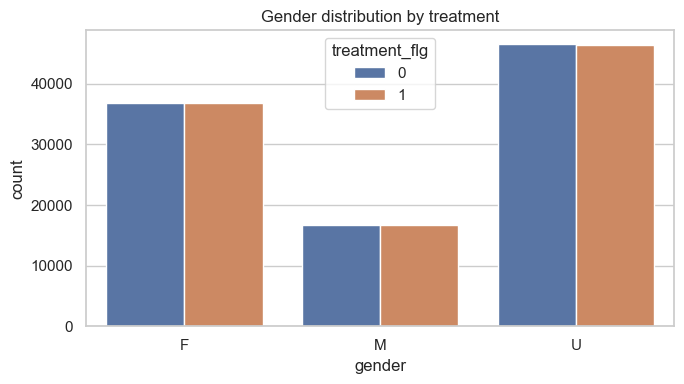

In [13]:

if cols["gender"] in eda_df.columns:
    gender_share = eda_df.groupby([cols["treatment"], cols["gender"]]).size().rename("count").reset_index()
    plt.figure(figsize=(7, 4))
    sns.barplot(data=gender_share, x=cols["gender"], y="count", hue=cols["treatment"])
    plt.title("Gender distribution by treatment")
    plt.tight_layout()
    plt.savefig(fig_dir / "eda_gender_by_treatment.png", dpi=150, bbox_inches="tight")
    plt.show()


In [14]:

smd_df = smd_report(eda_df, numeric_features, cols["treatment"])
display(smd_df)
smd_df.to_csv(tbl_dir / "smd_report.csv", index=False)


,feature,smd,abs_smd
3,has_redeem_history,0.023444,0.023444
1,days_since_first_issue,0.008550,0.008550
0,age,0.004583,0.004583
2,days_since_first_redeem,0.001619,0.001619


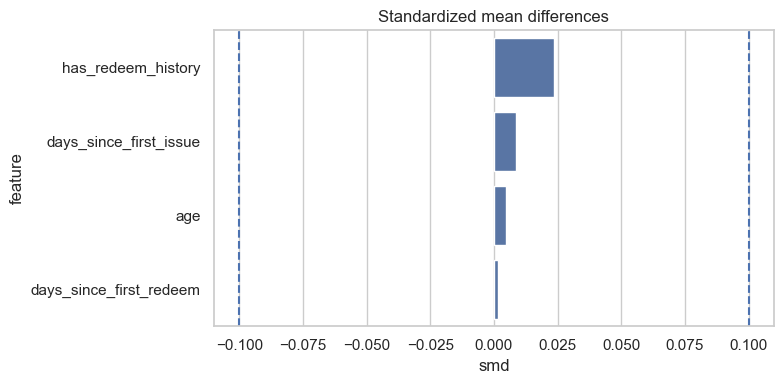

In [15]:

plt.figure(figsize=(8, 4))
sns.barplot(data=smd_df, y="feature", x="smd", orient="h")
plt.axvline(0.1, linestyle="--")
plt.axvline(-0.1, linestyle="--")
plt.title("Standardized mean differences")
plt.tight_layout()
plt.savefig(fig_dir / "eda_smd.png", dpi=150, bbox_inches="tight")
plt.show()


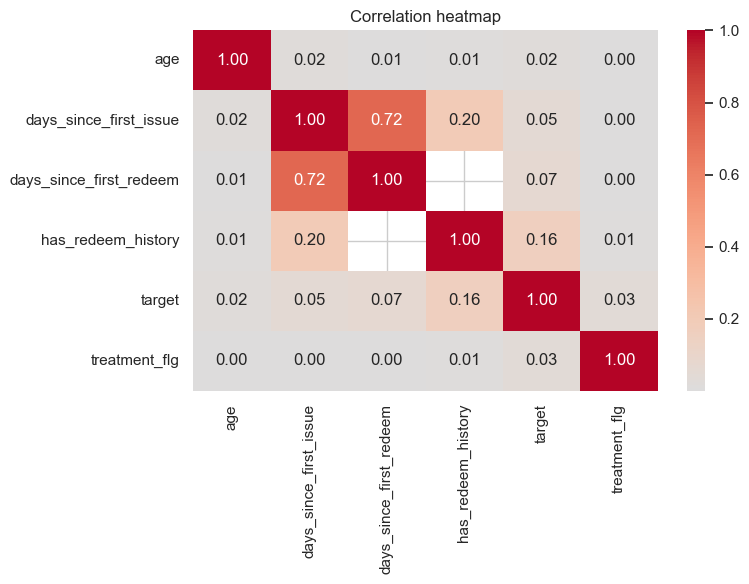

In [16]:

corr_features = [c for c in numeric_features + [cols["target"], cols["treatment"]] if c in eda_df.columns]
corr = eda_df[corr_features].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig(fig_dir / "eda_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


In [17]:

age_summary = eda_df.groupby(cols["treatment"])[cols["age"]].describe().reset_index()
display(age_summary)
age_summary.to_csv(tbl_dir / "age_summary_by_treatment.csv", index=False)


,treatment_flg,count,mean,std,min,25%,50%,75%,max
0,0,100058.0,46.303874,57.575128,-7491.0,34.0,45.0,59.0,1717.0
1,1,99981.0,46.530871,39.892005,-5973.0,34.0,45.0,59.0,1852.0


## Выводы
Здесь удобно записать: баланс treatment/control, observed uplift, selection bias и гипотезы для следующего этапа.